# Vaccine center experiments

We combine Census county boundaries, county demographics (`uscounties.csv`), and Queen adjacency to compare:

1. **Minimum set cover**: fewest centers so every county is covered by itself or a Queen-neighbor.
2. **Equitable p-median**: minimize population-weighted travel miles with at most `k` centers, with Queen coverage enforced.
3. **P-center (minimax)**: minimize the maximum assigned travel distance with the same `k` cap and Queen coverage.

Story order: setup -> data load -> RI -> PA -> TX -> PA full sweep -> comparison.


## Setup


In [1]:
import os
import sys
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def show_table(df):
    formats = {}
    if "Distance_miles" in df.columns:
        formats["Distance_miles"] = "{:,.4f}"
    if "Weighted_Dist" in df.columns:
        formats["Weighted_Dist"] = "{:,.0f}"
    if "Distance_Miles" in df.columns:
        formats["Distance_Miles"] = "{:,.4f}"
    if "Weighted_Distance" in df.columns:
        formats["Weighted_Distance"] = "{:,.0f}"
    if formats:
        display(df.style.format(formats))
    else:
        display(df)

ROOT = os.path.abspath(".")
PY_SCRIPTS = os.path.join(ROOT, "py_scripts")
sys.path.insert(0, PY_SCRIPTS)

from parse_adjacency import parse_adjacency, load_adjacency
from parse_county_data import parse_county_data, load_county_data
from min_coverage import solve_min_coverage
from equitable_placement import solve_equitable, solve_equitable_p_center
from helper_functions import (
    normalize_county_fips,
    plot_centers,
    state_name_to_fips,
    _haversine_miles,
)

SHP_PATH = os.path.join(ROOT, "county_data", "cb_2023_us_county_500k", "cb_2023_us_county_500k.shp")
DEMO_PATH = os.path.join(ROOT, "county_data", "uscounties.csv")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")


## Parameters (manual k per state)

Set analyst-controlled `k` values here. For each state run, the notebook validates that:

`k_min_cover <= k <= number_of_counties`


In [2]:
k_ri = 5
k_pa = 20
k_tx = 60


## Data helpers and model runner


In [3]:
def _fips_alignment_report(state_shp, cdata, adj):
    geo_fips = set(state_shp["GEOID"].astype(str).map(normalize_county_fips))
    cd_fips = set(cdata.keys())
    ad_fips = set(adj.keys())

    aligned = geo_fips == cd_fips == ad_fips
    report = {
        "aligned": aligned,
        "geo_only": sorted(geo_fips - cd_fips - ad_fips),
        "cdata_only": sorted(cd_fips - geo_fips - ad_fips),
        "adj_only": sorted(ad_fips - geo_fips - cd_fips),
        "missing_in_geo": sorted((cd_fips | ad_fips) - geo_fips),
        "missing_in_cdata": sorted((geo_fips | ad_fips) - cd_fips),
        "missing_in_adj": sorted((geo_fips | cd_fips) - ad_fips),
    }
    return report


def load_state(state_name):
    state_fips = state_name_to_fips(state_name)

    parse_adjacency(state_fips)
    adj = load_adjacency(state_fips)

    parse_county_data(DEMO_PATH, state_fips)
    cdata = load_county_data(state_fips)

    shp = gpd.read_file(SHP_PATH)
    state_shp = shp[shp["STATEFP"] == state_fips].copy()

    report = _fips_alignment_report(state_shp, cdata, adj)
    print(f"[{state_name}] FIPS aligned: {report['aligned']}")
    if not report["aligned"]:
        print(f"  missing_in_geo: {report['missing_in_geo']}")
        print(f"  missing_in_cdata: {report['missing_in_cdata']}")
        print(f"  missing_in_adj: {report['missing_in_adj']}")

    return adj, cdata, state_shp


def _serving_center_min_cover(fips, centers_set, adj, cdata):
    if fips in centers_set:
        return fips
    nbr_centers = [j for j in adj.get(fips, []) if j in centers_set]
    candidates = nbr_centers if nbr_centers else list(centers_set)
    lat, lon = cdata[fips]["lat"], cdata[fips]["lon"]
    return min(candidates, key=lambda j: _haversine_miles(lat, lon, cdata[j]["lat"], cdata[j]["lon"]))


def dataframe_min_coverage(centers_a, adj, cdata):
    centers_set = set(centers_a)
    rows = []
    for fips, data in sorted(cdata.items()):
        ctr = _serving_center_min_cover(fips, centers_set, adj, cdata)
        dist_mi = 0.0 if ctr == fips else _haversine_miles(data["lat"], data["lon"], cdata[ctr]["lat"], cdata[ctr]["lon"])
        rows.append({
            "FIPS": fips,
            "County": data["name"],
            "Population": data["population"],
            "Is_Center": fips in centers_set,
            "Serving_Center_FIPS": ctr,
            "Serving_Center": cdata[ctr]["name"],
            "Distance_miles": dist_mi,
            "Weighted_Dist": data["population"] * dist_mi,
        })
    return pd.DataFrame(rows)


def dataframe_assignment(centers, assigned, cdata):
    centers_set = set(centers)
    missing_assignments = sorted(set(cdata) - set(assigned))
    if missing_assignments:
        raise ValueError(f"Missing assignments for counties: {missing_assignments}")

    bad_centers = sorted({assigned[f] for f in cdata if assigned[f] not in centers_set})
    if bad_centers:
        raise ValueError(f"Assignments reference non-center FIPS: {bad_centers}")

    unknown_fips = sorted({assigned[f] for f in cdata if assigned[f] not in cdata})
    if unknown_fips:
        raise ValueError(f"Assignments reference unknown county FIPS: {unknown_fips}")

    rows = []
    for fips, data in sorted(cdata.items()):
        af = assigned[fips]
        dist_mi = 0.0 if af == fips else _haversine_miles(data["lat"], data["lon"], cdata[af]["lat"], cdata[af]["lon"])
        rows.append({
            "FIPS": fips,
            "County": data["name"],
            "Population": data["population"],
            "Is_Center": fips in centers_set,
            "Serving_Center_FIPS": af,
            "Serving_Center": cdata[af]["name"],
            "Distance_Miles": dist_mi,
            "Weighted_Distance": data["population"] * dist_mi,
        })
    return pd.DataFrame(rows)


def run_state_optimization(state_name, k):
    adj, cdata, state_shp = load_state(state_name)
    n = len(cdata)

    centers_a, obj_a, time_a = solve_min_coverage(adj, cdata)
    k_min_cover = int(round(obj_a))
    k_max = n

    print(f"[{state_name}] k bounds: k_min_cover={k_min_cover}, k_max={k_max}, k_used={k}")
    if not (k_min_cover <= k <= k_max):
        raise ValueError(
            f"[{state_name}] invalid k={k}; must satisfy {k_min_cover} <= k <= {k_max}"
        )

    centers_b, obj_b, time_b, assigned_b = solve_equitable(cdata, k, adj)
    centers_pc, obj_pc, time_pc, assigned_pc = solve_equitable_p_center(cdata, k, adj)

    return {
        "state_name": state_name,
        "adj": adj,
        "cdata": cdata,
        "state_shp": state_shp,
        "n": n,
        "k": k,
        "k_min_cover": k_min_cover,
        "k_max": k_max,
        "centers_a": centers_a,
        "obj_a": obj_a,
        "time_a": time_a,
        "df_a": dataframe_min_coverage(centers_a, adj, cdata),
        "centers_b": centers_b,
        "obj_b": obj_b,
        "time_b": time_b,
        "df_b": dataframe_assignment(centers_b, assigned_b, cdata),
        "centers_pc": centers_pc,
        "obj_pc": obj_pc,
        "time_pc": time_pc,
        "df_pc": dataframe_assignment(centers_pc, assigned_pc, cdata),
    }


def display_state_tables_and_maps(res):
    shp, cd = res["state_shp"], res["cdata"]
    k = res["k"]
    name = res["state_name"]

    print(f"{name} min coverage: centers={len(res['centers_a'])}, objective={res['obj_a']}, time={res['time_a']:.4f}s")
    show_table(res["df_a"])
    plot_centers(shp, cd, res["centers_a"], "min coverage")

    print(f"{name} p-median (k={k}): objective={res['obj_b']:,.2f} person-miles, time={res['time_b']:.4f}s")
    show_table(res["df_b"])
    plot_centers(shp, cd, res["centers_b"], f"k={k} p-median")

    print(f"{name} p-center (k={k}): max distance={res['obj_pc']:.4f} miles, time={res['time_pc']:.4f}s")
    show_table(res["df_pc"])
    plot_centers(shp, cd, res["centers_pc"], f"k={k} p-center")


## Rhode Island


[Rhode Island] FIPS aligned: True
Set parameter Username
Set parameter LicenseID to value 2764175
Academic license - for non-commercial use only - expires 2027-01-13
[Rhode Island] k bounds: k_min_cover=3, k_max=5, k_used=5
Rhode Island min coverage: centers=3, objective=3.0, time=0.0053s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_miles,Weighted_Dist
0,44001,Bristol County,50490,False,44007,Providence County,18.6248,"940,365"
1,44003,Kent County,171456,True,44003,Kent County,0.0000,0
2,44005,Newport County,84657,True,44005,Newport County,0.0000,0
3,44007,Providence County,664854,True,44007,Providence County,0.0000,0
4,44009,Washington County,130344,False,44003,Kent County,14.0737,"1,834,424"


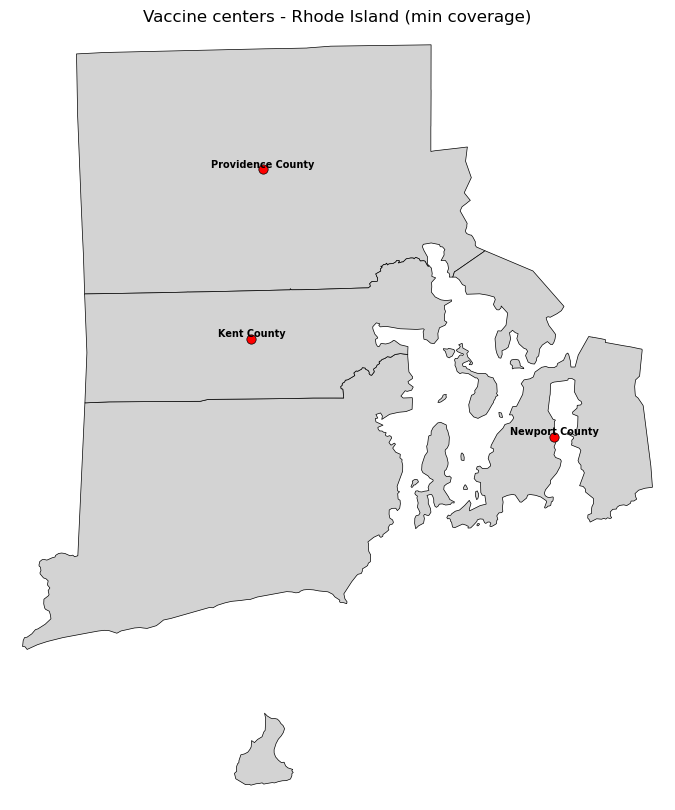

Rhode Island p-median (k=5): objective=0.00 person-miles, time=0.0001s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,44001,Bristol County,50490,True,44001,Bristol County,0.0000,0
1,44003,Kent County,171456,True,44003,Kent County,0.0000,0
2,44005,Newport County,84657,True,44005,Newport County,0.0000,0
3,44007,Providence County,664854,True,44007,Providence County,0.0000,0
4,44009,Washington County,130344,True,44009,Washington County,0.0000,0


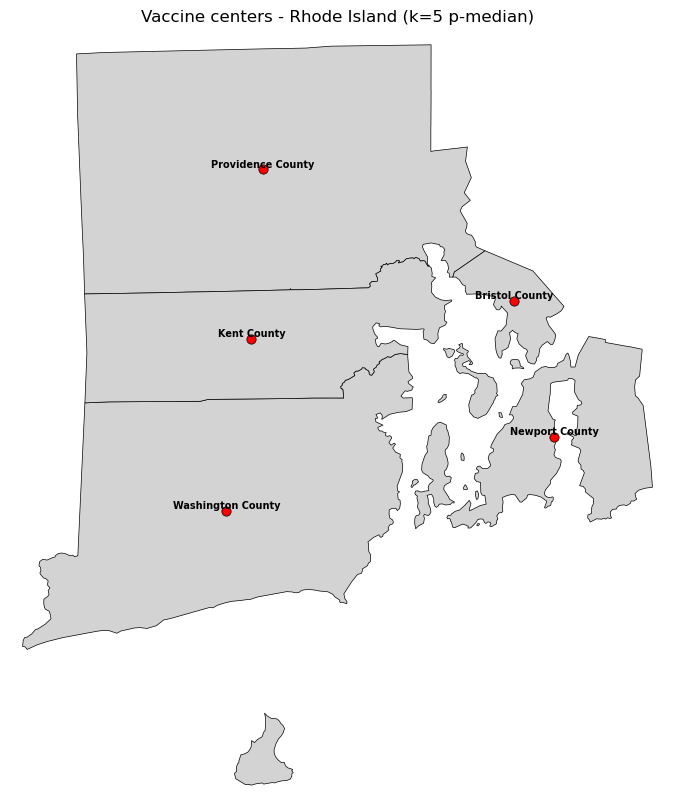

Rhode Island p-center (k=5): max distance=0.0000 miles, time=0.0001s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,44001,Bristol County,50490,True,44001,Bristol County,0.0000,0
1,44003,Kent County,171456,True,44003,Kent County,0.0000,0
2,44005,Newport County,84657,True,44005,Newport County,0.0000,0
3,44007,Providence County,664854,True,44007,Providence County,0.0000,0
4,44009,Washington County,130344,True,44009,Washington County,0.0000,0


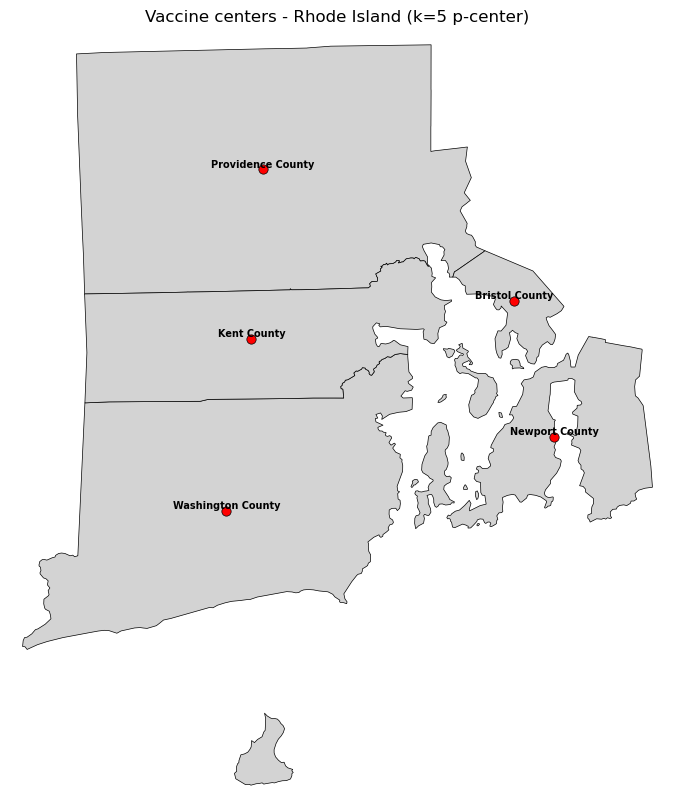

In [4]:
res_ri = run_state_optimization("Rhode Island", k_ri)
display_state_tables_and_maps(res_ri)


## Pennsylvania


[Pennsylvania] FIPS aligned: True
[Pennsylvania] k bounds: k_min_cover=12, k_max=67, k_used=20
Pennsylvania min coverage: centers=12, objective=12.0, time=0.0006s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_miles,Weighted_Dist
0,42001,Adams County,106115,False,42133,York County,26.2634,"2,786,943"
1,42003,Allegheny County,1238177,False,42019,Butler County,30.8281,"38,170,674"
2,42005,Armstrong County,64622,False,42019,Butler County,24.4414,"1,579,454"
3,42007,Beaver County,166324,False,42019,Butler County,27.7841,"4,621,165"
4,42009,Bedford County,47513,False,42061,Huntingdon County,39.0593,"1,855,824"
5,42011,Berks County,433015,False,42107,Schuylkill County,25.1361,"10,884,304"
6,42013,Blair County,121277,False,42061,Huntingdon County,19.8049,"2,401,875"
7,42015,Bradford County,59858,False,42131,Wyoming County,31.8184,"1,904,584"
8,42017,Bucks County,647461,False,42091,Montgomery County,16.2587,"10,526,887"
9,42019,Butler County,197254,True,42019,Butler County,0.0000,0


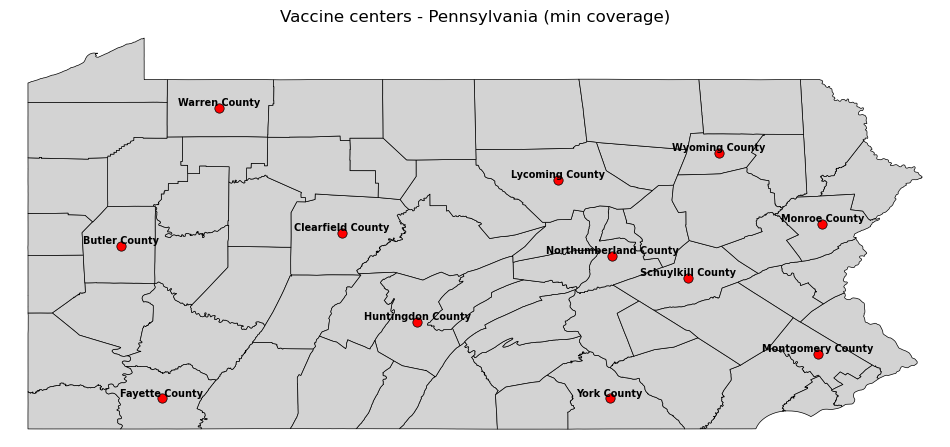

Pennsylvania p-median (k=20): objective=110,016,769.70 person-miles, time=0.0741s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,42001,Adams County,106115,False,42041,Cumberland County,20.3388,"2,158,247"
1,42003,Allegheny County,1238177,True,42003,Allegheny County,0.0000,0
2,42005,Armstrong County,64622,False,42019,Butler County,24.4414,"1,579,454"
3,42007,Beaver County,166324,False,42003,Allegheny County,24.3060,"4,042,671"
4,42009,Bedford County,47513,False,42061,Huntingdon County,39.0593,"1,855,824"
5,42011,Berks County,433015,True,42011,Berks County,0.0000,0
6,42013,Blair County,121277,False,42061,Huntingdon County,19.8049,"2,401,875"
7,42015,Bradford County,59858,False,42081,Lycoming County,41.8612,"2,505,730"
8,42017,Bucks County,647461,True,42017,Bucks County,0.0000,0
9,42019,Butler County,197254,True,42019,Butler County,0.0000,0


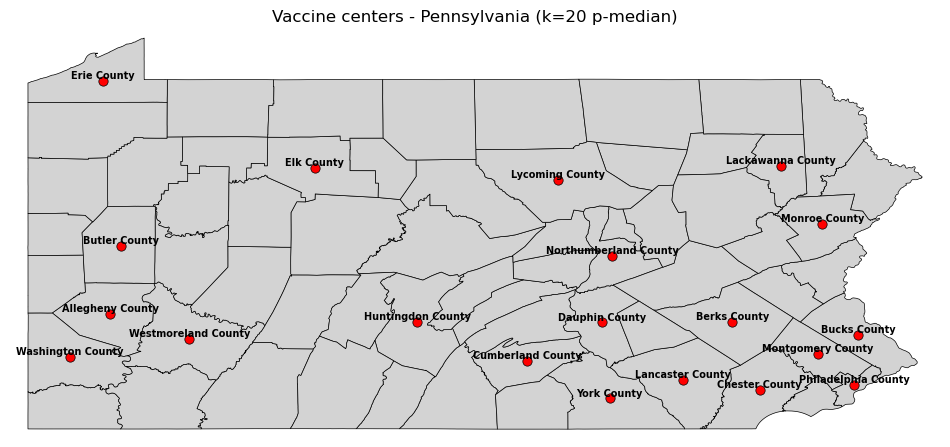

Pennsylvania p-center (k=20): max distance=29.4947 miles, time=0.2712s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,42001,Adams County,106115,True,42001,Adams County,0.0000,0
1,42003,Allegheny County,1238177,False,42125,Washington County,23.8873,"29,576,706"
2,42005,Armstrong County,64622,False,42019,Butler County,24.4414,"1,579,454"
3,42007,Beaver County,166324,False,42019,Butler County,27.7841,"4,621,165"
4,42009,Bedford County,47513,True,42009,Bedford County,0.0000,0
5,42011,Berks County,433015,False,42075,Lebanon County,28.1849,"12,204,488"
6,42013,Blair County,121277,False,42021,Cambria County,19.2098,"2,329,703"
7,42015,Bradford County,59858,False,42113,Sullivan County,23.6651,"1,416,544"
8,42017,Bucks County,647461,False,42091,Montgomery County,16.2587,"10,526,887"
9,42019,Butler County,197254,True,42019,Butler County,0.0000,0


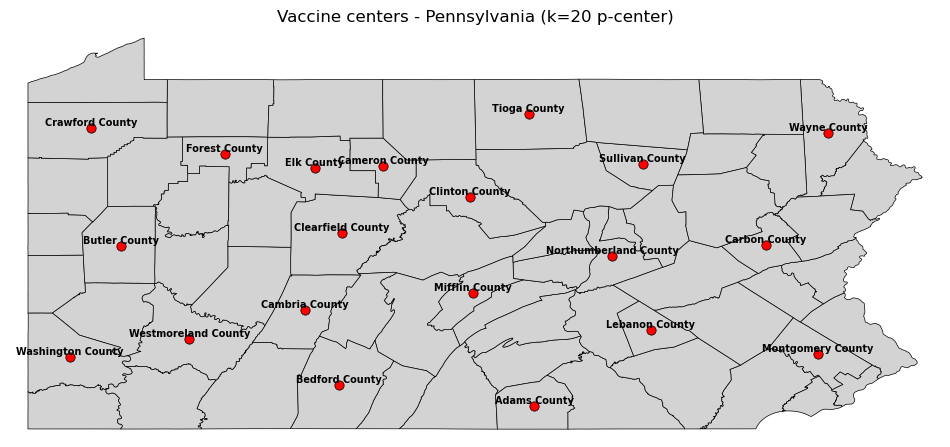

PA times: min-cover=0.0006s, p-median=0.0741s, p-center=0.2712s


In [5]:
res_pa = run_state_optimization("Pennsylvania", k_pa)
display_state_tables_and_maps(res_pa)
print(f"PA times: min-cover={res_pa['time_a']:.4f}s, p-median={res_pa['time_b']:.4f}s, p-center={res_pa['time_pc']:.4f}s")


## Texas


[Texas] FIPS aligned: True
[Texas] k bounds: k_min_cover=41, k_max=254, k_used=60
Texas min coverage: centers=41, objective=41.0, time=0.0981s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_miles,Weighted_Dist
0,48001,Anderson County,58439,False,48225,Houston County,36.8182,"2,151,618"
1,48003,Andrews County,18610,False,48317,Martin County,40.0847,"745,976"
2,48005,Angelina County,87275,False,48225,Houston County,48.0713,"4,195,424"
3,48007,Aransas County,24876,False,48355,Nueces County,46.8709,"1,165,960"
4,48009,Archer County,8867,False,48023,Baylor County,30.2540,"268,262"
5,48011,Armstrong County,1822,True,48011,Armstrong County,0.0000,0
6,48013,Atascosa County,51008,False,48255,Karnes County,40.4033,"2,060,894"
7,48015,Austin County,31170,False,48477,Washington County,23.8404,"743,106"
8,48017,Bailey County,6913,False,48369,Parmer County,31.9917,"221,159"
9,48019,Bandera County,22021,False,48463,Uvalde County,41.0759,"904,532"


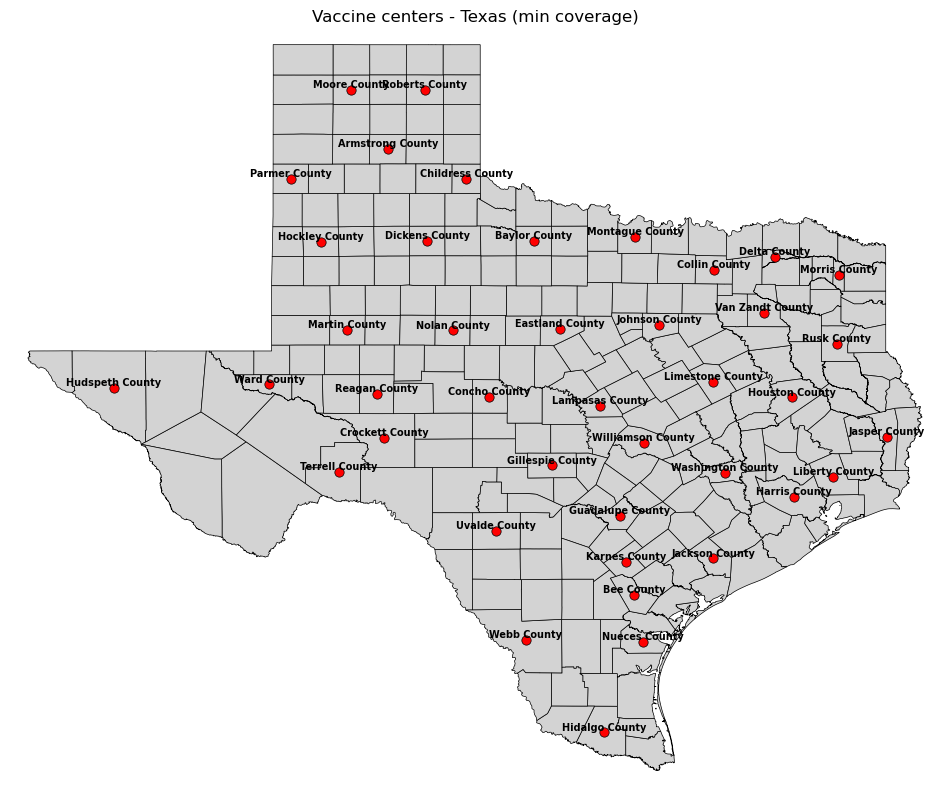

Texas p-median (k=60): objective=148,623,777.17 person-miles, time=0.6267s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,48001,Anderson County,58439,False,48213,Henderson County,29.9549,"1,750,533"
1,48003,Andrews County,18610,False,48135,Ector County,30.6180,"569,801"
2,48005,Angelina County,87275,True,48005,Angelina County,0.0000,0
3,48007,Aransas County,24876,False,48469,Victoria County,46.3806,"1,153,764"
4,48009,Archer County,8867,False,48485,Wichita County,25.7671,"228,477"
5,48011,Armstrong County,1822,True,48011,Armstrong County,0.0000,0
6,48013,Atascosa County,51008,False,48029,Bexar County,38.3769,"1,957,531"
7,48015,Austin County,31170,True,48015,Austin County,0.0000,0
8,48017,Bailey County,6913,False,48369,Parmer County,31.9917,"221,159"
9,48019,Bandera County,22021,False,48265,Kerr County,22.5868,"497,384"


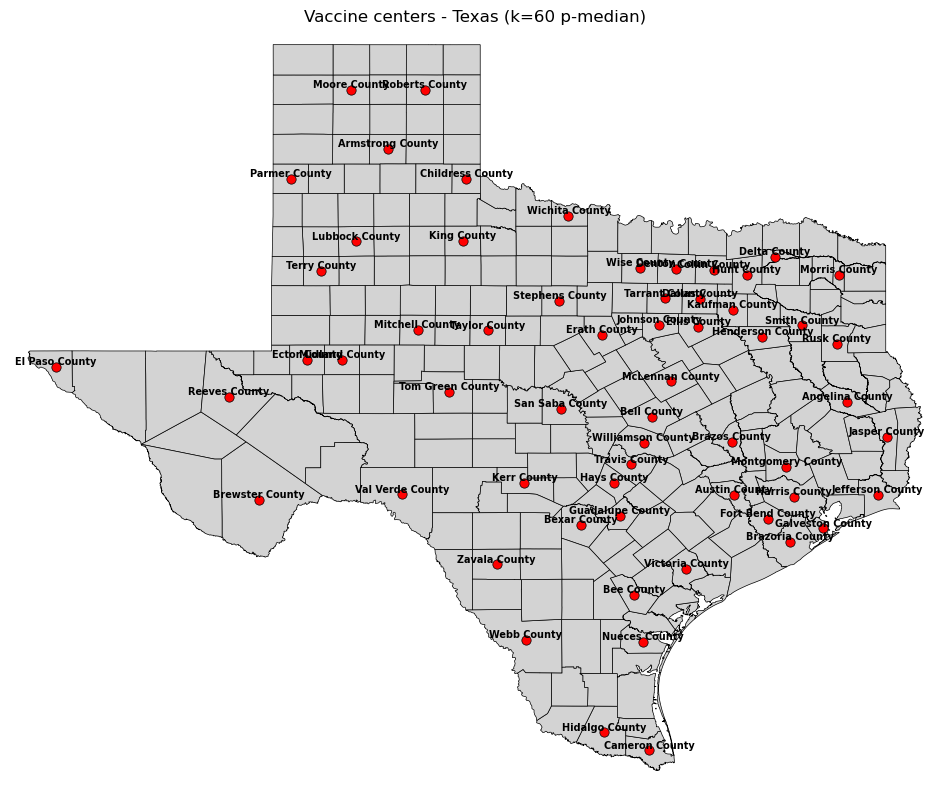

Texas p-center (k=60): max distance=40.2917 miles, time=15.6103s


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,48001,Anderson County,58439,False,48213,Henderson County,29.9549,"1,750,533"
1,48003,Andrews County,18610,False,48135,Ector County,30.6180,"569,801"
2,48005,Angelina County,87275,False,48455,Trinity County,33.0106,"2,880,996"
3,48007,Aransas County,24876,False,48391,Refugio County,17.3433,"431,431"
4,48009,Archer County,8867,False,48023,Baylor County,30.2540,"268,262"
5,48011,Armstrong County,1822,True,48011,Armstrong County,0.0000,0
6,48013,Atascosa County,51008,False,48311,McMullen County,37.4541,"1,910,457"
7,48015,Austin County,31170,False,48473,Waller County,19.3704,"603,777"
8,48017,Bailey County,6913,False,48079,Cochran County,32.0871,"221,818"
9,48019,Bandera County,22021,False,48265,Kerr County,22.5868,"497,384"


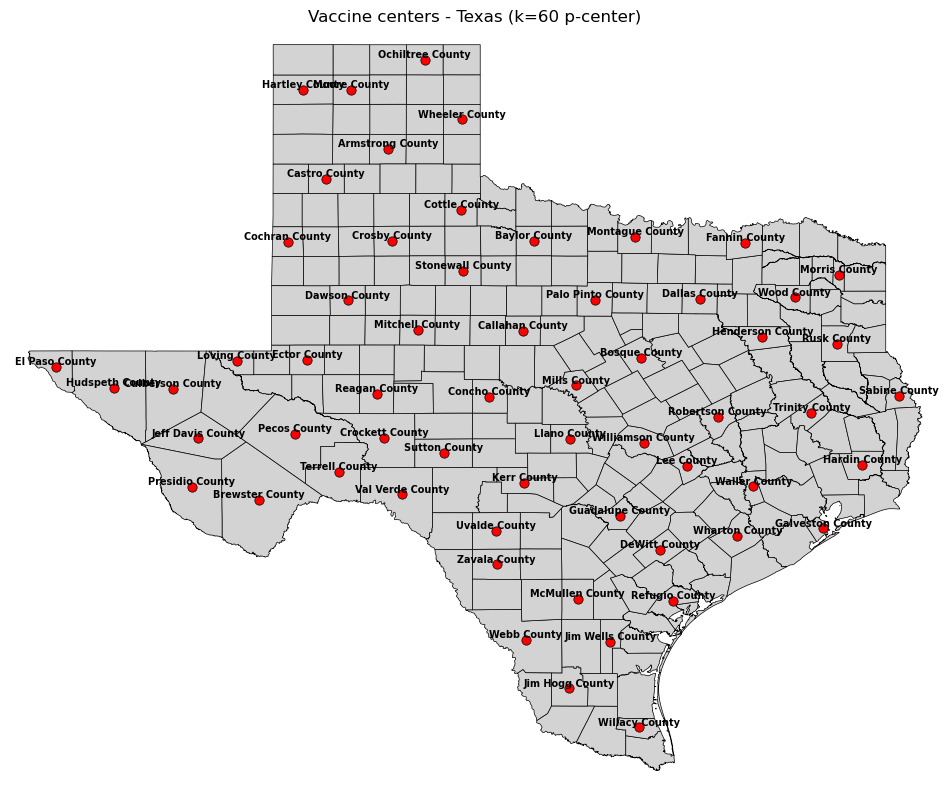

TX times: min-cover=0.0981s, p-median=0.6267s, p-center=15.6103s


In [6]:
res_tx = run_state_optimization("Texas", k_tx)
display_state_tables_and_maps(res_tx)
print(f"TX times: min-cover={res_tx['time_a']:.4f}s, p-median={res_tx['time_b']:.4f}s, p-center={res_tx['time_pc']:.4f}s")


## Pennsylvania full k sweep (p-median + p-center)

For comparison testing, run full Pennsylvania sweep from `k_min_cover` through `n_counties`:
- `k_i = k_min_cover + i`
- up to `k_max = n_counties`


Pennsylvania full sweep count: 56 (k from 12 to 67)


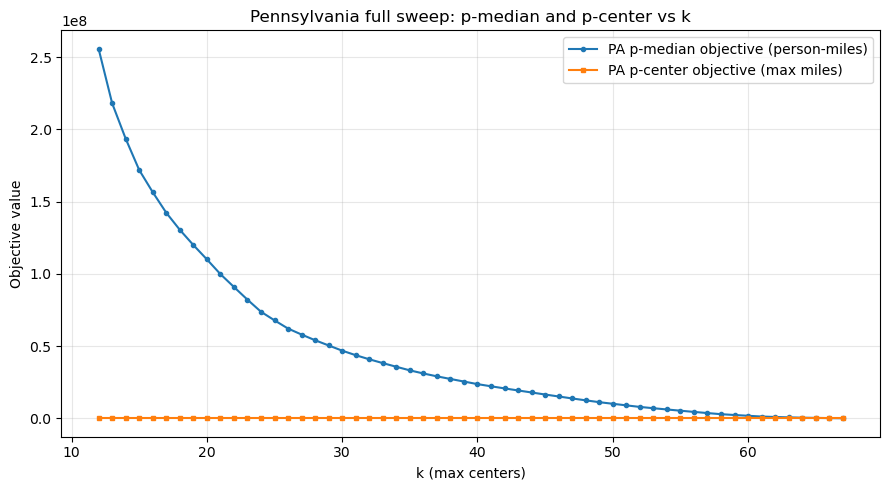

In [7]:
adj_pa = res_pa["adj"]
cd_pa = res_pa["cdata"]
k0_pa = res_pa["k_min_cover"]
kmax_pa = res_pa["n"]
ks_pa = list(range(k0_pa, kmax_pa + 1))

print(f"Pennsylvania full sweep count: {len(ks_pa)} (k from {ks_pa[0]} to {ks_pa[-1]})")

obj_med_pa = []
obj_pc_pa = []
for kk in ks_pa:
    _, med, _, _ = solve_equitable(cd_pa, kk, adj_pa)
    _, pc, _, _ = solve_equitable_p_center(cd_pa, kk, adj_pa)
    obj_med_pa.append(med)
    obj_pc_pa.append(pc)

plt.figure(figsize=(9, 5))
plt.plot(ks_pa, obj_med_pa, marker="o", ms=3, label="PA p-median objective (person-miles)")
plt.plot(ks_pa, obj_pc_pa, marker="s", ms=3, label="PA p-center objective (max miles)")
plt.xlabel("k (max centers)")
plt.ylabel("Objective value")
plt.title("Pennsylvania full sweep: p-median and p-center vs k")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## RI / PA / TX comparison


In [8]:
rows = []
for res in (res_ri, res_pa, res_tx):
    rows.append({
        "State": res["state_name"],
        "n_counties": res["n"],
        "k_min_cover": res["k_min_cover"],
        "k_max": res["k_max"],
        "k_used": res["k"],
        "time_min_cover_s": res["time_a"],
        "time_p_median_s": res["time_b"],
        "time_p_center_s": res["time_pc"],
        "obj_p_median_person_miles": res["obj_b"],
        "obj_p_center_max_miles": res["obj_pc"],
    })
show_table(pd.DataFrame(rows))


,State,n_counties,k_min_cover,k_max,k_used,time_min_cover_s,time_p_median_s,time_p_center_s,obj_p_median_person_miles,obj_p_center_max_miles
0,Rhode Island,5,3,5,5,0.005313,0.000126,0.000094,0.000000e+00,0.000000
1,Pennsylvania,67,12,67,20,0.000638,0.074118,0.271167,1.100168e+08,29.494697
2,Texas,254,41,254,60,0.098069,0.626699,15.610252,1.486238e+08,40.291689
